## Class definition

In [184]:
from dataclasses import dataclass

LOCATION_TYPES = {1: "country", 2: "us_state", 3: "us_city", 4: "world_city", 5: "world_state"}

@dataclass
class Location:
    type: int
    type_label: str
    name: str
    country_code: str
    adm1_code: str
    lat: float
    lon: float
    feature_id: str

def parse_location(loc_str: str):
    parts = loc_str.split("#")
    if len(parts) < 7 or parts[4] == "" or parts[5] == "":
        return None
    loc_type = int(parts[0])
    return Location(
        type=loc_type,
        type_label=LOCATION_TYPES.get(loc_type, "unknown"),
        name=parts[1],
        country_code=parts[2],
        adm1_code=parts[3],
        lat=float(parts[4]),
        lon=float(parts[5]),
        feature_id=parts[6],
    )

def parse_locations(loc_list: list) -> list:
    return [loc for s in loc_list if s and (loc := parse_location(s)) is not None]

## Importing data and initial processing

In [185]:
import pandas as pd

In [186]:
raw_gdelt = pd.read_csv('data/bq-results-ARREST.csv')
raw_gdelt["DATE"] = pd.to_datetime(raw_gdelt["DATE"], format="%Y%m%d%H%M%S")
raw_gdelt.head()

,DATE,SourceCommonName,DocumentIdentifier,Locations,Organizations,Themes
0,2025-01-29 07:00:00,apnews.com,https://apnews.com/article/guatemala-us-milita...,1#Guatemala#GT#GT#15.5#-90.25#GT;1#Colombia#CO...,department of homeland security;guatemala immi...,MANMADE_DISASTER_IMPLIED;MILITARY;SOC_POINTSOF...
1,2025-03-04 05:45:00,apnews.com,https://apnews.com/article/immigration-crackdo...,"1#Mexico#MX#MX#23#-102#MX;2#Idaho, United Stat...",white house;walmart;trump organization;starbuc...,IMMIGRATION;WB_2670_JOBS;WB_2769_JOBS_STRATEGI...
2,2025-02-13 04:30:00,apnews.com,https://apnews.com/article/guantanamo-aclu-tru...,"2#Texas, United States#US#USTX#31.106#-97.6475...",associated press;las americas immigrant advoca...,SELF_IDENTIFIED_HUMAN_RIGHTS;UNGP_POLITICAL_FR...
3,2025-01-24 23:45:00,apnews.com,https://apnews.com/article/donald-trump-fact-f...,"3#Santa Ynez, California, United States#US#USC...",department of homeland security;emergency mana...,LEADER;TAX_FNCACT;TAX_FNCACT_PRESIDENT;USPEC_P...
4,2025-02-26 05:15:00,apnews.com,https://apnews.com/article/illegal-immigrant-r...,"3#Washington, Washington, United States#US#USD...",immigration service;national immigration law c...,WB_696_PUBLIC_SECTOR_MANAGEMENT;WB_840_JUSTICE...


### Process location data by splitting it up appropriately then turning them into Location objects

In [187]:
raw_gdelt["Locations"] = raw_gdelt["Locations"].str.split(";")

In [188]:
# removes null or empty lists
locations_cleaned = raw_gdelt[raw_gdelt["Locations"].apply(lambda s: isinstance(s, list) and len(s) > 0)]


In [189]:
# creates list of location objects
locations_cleaned["parsed_locations"] = locations_cleaned["Locations"].map(parse_locations)

In [190]:
locations_only_df = locations_cleaned.explode("parsed_locations").reset_index()[["index", "DATE", "parsed_locations"]].rename(
    {"parsed_locations":"location_mentioned", "index": "doc_index"}, axis=1
)
locations_only_df.head()

,doc_index,DATE,location_mentioned
0,0,2025-01-29 07:00:00,"Location(type=1, type_label='country', name='G..."
1,0,2025-01-29 07:00:00,"Location(type=1, type_label='country', name='C..."
2,0,2025-01-29 07:00:00,"Location(type=1, type_label='country', name='M..."
3,0,2025-01-29 07:00:00,"Location(type=1, type_label='country', name='U..."
4,0,2025-01-29 07:00:00,"Location(type=4, type_label='world_city', name..."


In [191]:
# filter for only instances of US cities and states mentioned
def locations_in_america(loc):
    return loc.type in (2, 3) and loc.adm1_code != "USDC"

only_us = locations_only_df[locations_only_df["location_mentioned"].map(locations_in_america)]

## Plotting data

In [192]:
import folium
from folium.plugins import HeatMap

state_coords = only_us[only_us["location_mentioned"].apply(lambda l: l.type == 2)]["location_mentioned"].apply(lambda l: [l.lat, l.lon]).tolist()
city_coords = only_us[only_us["location_mentioned"].apply(lambda l: l.type == 3)]["location_mentioned"].apply(lambda l: [l.lat, l.lon]).tolist()

m = folium.Map(location=[39.5, -98.5], zoom_start=4, tiles='CartoDB positron')
HeatMap(state_coords, radius=15, blur=10).add_to(m)
HeatMap(city_coords, radius=6, blur=8).add_to(m)
m

In [193]:
m.save('../static/arrest_location_map.html')


In [ ]:
only_us_copy = only_us.copy()


In [ ]:
only_us_copy["code"] = only_us_copy["location_mentioned"].apply(lambda l: l.adm1_code)
state_counts = only_us_copy.groupby("code").size().reset_index(name="count")

state_counts["state_code"] = state_counts["code"].str[2:]

In [216]:
final_counts_state = state_counts.rename({"count": "num_article_mentions"}, axis=1) 

In [217]:
import plotly.express as px
fig = px.choropleth(final_counts_state,
                    locations='state_code', 
                    locationmode="USA-states", 
                    scope="usa",
                    color='num_article_mentions',
                    color_continuous_scale="Viridis_r", 

                    )
fig.show()

In [198]:
fig.write_html('../static/state_heatmap.html')


In [199]:
import folium
from folium.plugins import HeatMap

state_coords = only_us[only_us["location_mentioned"].apply(lambda l: l.type == 2)]["location_mentioned"].apply(lambda l: [l.lat, l.lon]).tolist()
city_coords = only_us[only_us["location_mentioned"].apply(lambda l: l.type == 3)]["location_mentioned"].apply(lambda l: [l.lat, l.lon]).tolist()

m = folium.Map(location=[39.5, -98.5], zoom_start=4, tiles='CartoDB positron')
HeatMap(state_coords, radius=15, blur=10).add_to(m)
HeatMap(city_coords, radius=8, blur=4).add_to(m)
m

## EDA to ensure no dramatic differences after dropping 

In [200]:
monthly_counts = (
    raw_gdelt
    .assign(month=raw_gdelt["DATE"].dt.to_period("M").astype(str))
    .groupby("month")
    .size()
    .reset_index(name="article_count")
)

fig_monthly = px.bar(monthly_counts, x="month", y="article_count",
                     labels={"month": "Month", "article_count": "Number of Articles"},
                     title="Articles per Month")
fig_monthly.show()

In [201]:
monthly_counts = (
    locations_cleaned
    .assign(month=locations_cleaned["DATE"].dt.to_period("M").astype(str))
    .groupby("month")
    .size()
    .reset_index(name="article_count")
)

fig_monthly = px.bar(monthly_counts, x="month", y="article_count",
                     labels={"month": "Month", "article_count": "Number of Articles"},
                     title="Articles per Month")
fig_monthly.show()

In [202]:
cities_only = only_us[only_us.location_mentioned.map(lambda x : x.type == 3)]

In [203]:
city_coords = only_us[only_us["location_mentioned"].apply(lambda l: l.type == 3)]["location_mentioned"].apply(lambda l: [l.lat, l.lon]).tolist()

mNew = folium.Map(location=[39.5, -98.5], zoom_start=4, tiles='CartoDB positron')
HeatMap(state_coords, radius=6, blur=10).add_to(mNew)
mNew

In [204]:
mNew.save('../static/raw_location_map.html')

In [205]:
themesCounts = (raw_gdelt
                .Themes.str.split(";")
                .explode().reset_index()
                .groupby("Themes")[["index"]].agg(lambda x : len(x))
                .sort_values("index", ascending=False)
                .reset_index()
)
themesCounts

,Themes,index
0,ARREST,4413
1,TAX_FNCACT,4413
2,,4413
3,CRISISLEX_C07_SAFETY,4408
4,SOC_USSECURITYAGENCIES,4382
...,...,...
2770,WB_865_TRADE_CORRIDORS,1
2771,TAX_ETHNICITY_MONTENEGRIN,1
2772,WB_969_CAPITAL_MARKETS_LAW_AND_REGULATION,1
2773,WB_946_JUDICIAL_EDUCATION_AND_TRAINING,1


In [206]:
themesCounts["proportion"] = themesCounts["index"].map(lambda x : x/len(raw_gdelt))

In [207]:
import seaborn as sns

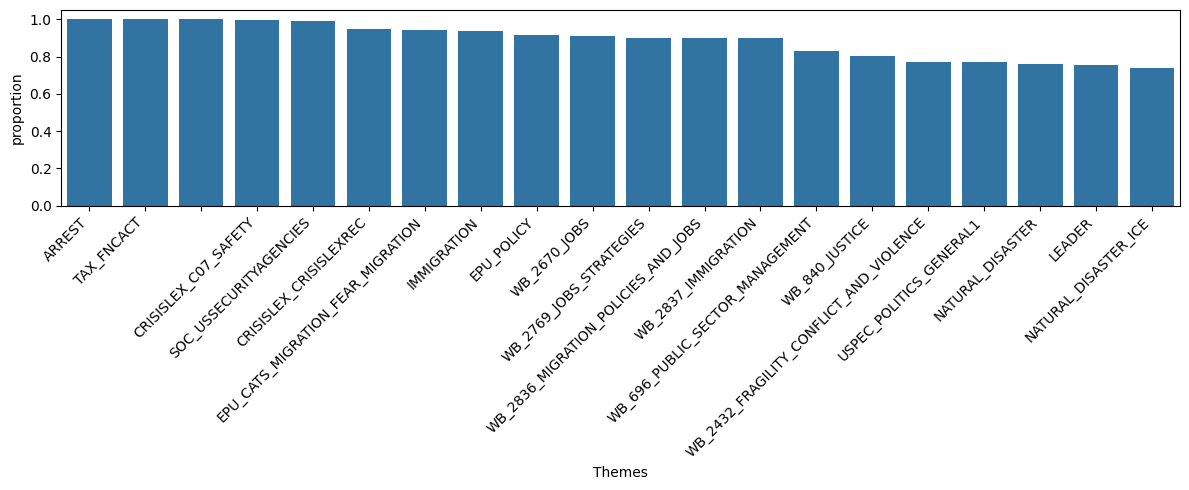

In [208]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.barplot(themesCounts[:20], x="Themes", y="proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [209]:
themesCounts[themesCounts["Themes"] == "UNREST_CRACKDOWN"]

,Themes,index,proportion
77,UNREST_CRACKDOWN,1164,0.263766


In [210]:
raw_gdelt.iloc[50].Themes

'TAX_FNCACT;TAX_FNCACT_JUDGE;IMMIGRATION;WB_2670_JOBS;WB_2769_JOBS_STRATEGIES;WB_2837_IMMIGRATION;WB_2836_MIGRATION_POLICIES_AND_JOBS;EPU_CATS_MIGRATION_FEAR_MIGRATION;CRISISLEX_CRISISLEXREC;NATURAL_DISASTER;NATURAL_DISASTER_ICE;TAX_MILITARY_TITLE;TAX_MILITARY_TITLE_OFFICERS;TAX_FNCACT_OFFICERS;ARREST;SOC_GENERALCRIME;CRISISLEX_C07_SAFETY;TAX_FNCACT_COOK;LEGISLATION;EPU_POLICY;EPU_POLICY_LAW;SECURITY_SERVICES;WB_696_PUBLIC_SECTOR_MANAGEMENT;WB_840_JUSTICE;WB_1920_FINANCIAL_SECTOR_DEVELOPMENT;WB_328_FINANCIAL_INTEGRITY;WB_1014_CRIMINAL_JUSTICE;WB_2082_LAW_ENFORCEMENT;TAX_FNCACT_AGENTS;EPU_CATS_MIGRATION_FEAR_FEAR;TAX_ETHNICITY;TAX_ETHNICITY_AMERICAN;TAX_FNCACT_CITIZENS;USPEC_POLICY1;EPU_POLICY_REGULATION;EPU_CATS_REGULATION;SOC_USSECURITYAGENCIES;CONSTITUTIONAL;BAN;'